##### PART 1: K-Means Clustering (palmerpenguins)

In [42]:
# 1. Load dataset and handle missing values
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
import numpy as np
import requests
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings

warnings.filterwarnings('ignore')

# Load penguins dataset
penguins = fetch_openml(name="penguins", version=1, as_frame=True).frame

In [2]:
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
# Rename the columns
penguins = penguins.rename(columns={
    "culmen_length_mm": "bill_length_mm",
    "culmen_depth_mm": "bill_depth_mm"
})

In [4]:
cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]
df = penguins[cols].copy()

# Impute numeric columns
num_cols = cols[:-1]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Drop missing species
df = df.dropna(subset=["species"])

In [5]:
# 2. Select numeric features
X = df[num_cols]

# Why exclude categorical?
# K-means uses Euclidean distance → not meaningful for categories

In [7]:
# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mean ≈ 0, Variance ≈ 1

In [10]:
# 4. K-means
kmeans = KMeans(n_clusters=3, n_init=50, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

# n_init important → avoids bad local minima

In [11]:
# 5. Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=num_cols)
print(centroids_df)

# Biological interpretation:
# Large body + flipper → Gentoo
# Small → Adelie
# Medium → Chinstrap

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       38.208333      18.110606         188.401515  3584.659091
1       47.504878      14.982114         217.186992  5076.016260
2       47.444313      18.725869         196.986859  3908.747290


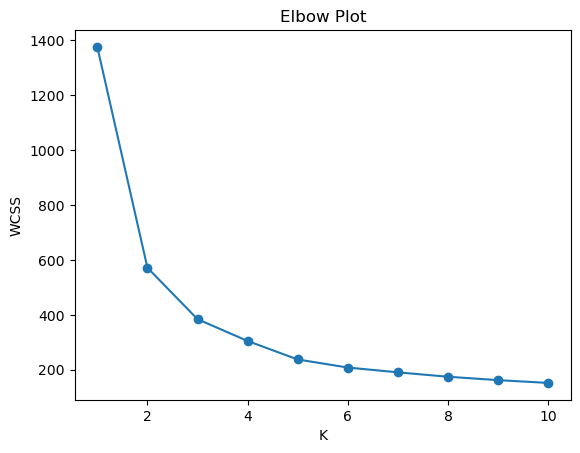

In [13]:
# 6. Elbow plot
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Plot")
plt.show()

# Elbow typically around K = 3

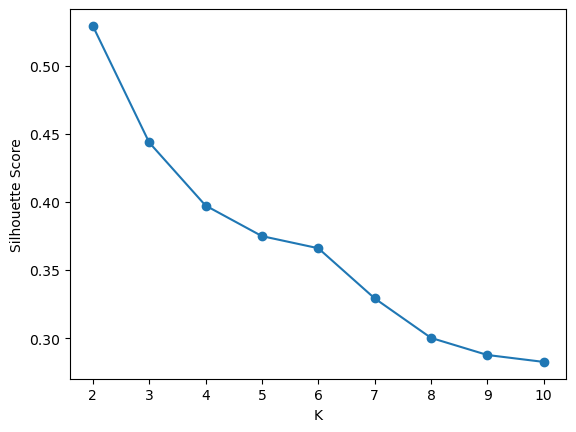

Best K: 2


In [14]:
# 7. Silhouette scores
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

print("Best K:", K_range[sil_scores.index(max(sil_scores))])

In [15]:
# 8. Contingency table
ct = pd.crosstab(df["cluster"], df["species"])
print(ct)

# Strong diagonal → good alignment

species  Adelie  Chinstrap  Gentoo
cluster                           
0           127          5       0
1             0          0     123
2            25         63       1


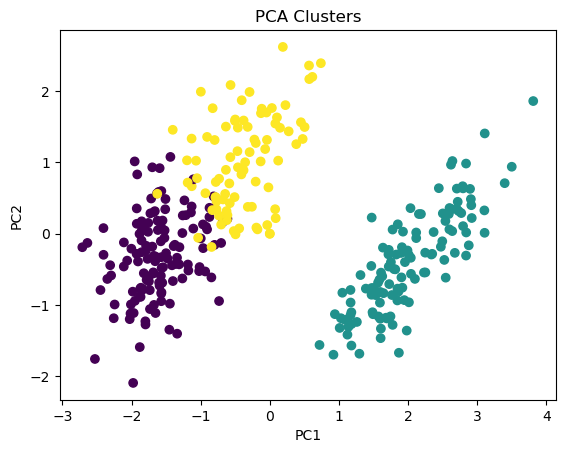

In [16]:
# 9. PCA visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clusters")
plt.show()

# Separation confirms clustering

In [17]:
# 10. Stability
kmeans2 = KMeans(n_clusters=3, n_init=50, random_state=100)
clusters2 = kmeans2.fit_predict(X_scaled)

print("Similarity:", (clusters == clusters2).mean())

# Slight variation due to random initialization

Similarity: 0.0


##### PART 2: Apriori

In [37]:
# 11. Load dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

# Read raw text
data = requests.get(url).text

# Convert into transactions
transactions = [line.strip().split(",") for line in data.strip().split("\n")]

print("Transactions:", len(transactions))

# Count unique items
unique_items = set(item for t in transactions for item in t)
print("Items:", len(unique_items))

Transactions: 9835
Items: 171


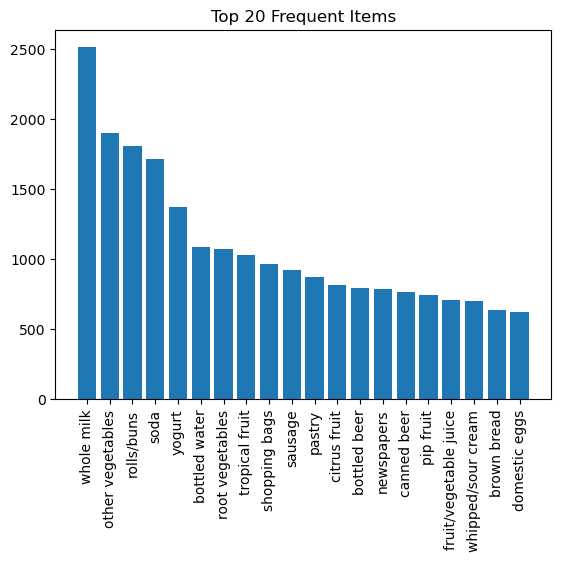

[('whole milk', 2513), ('other vegetables', 1903), ('rolls/buns', 1809), ('soda', 1715), ('yogurt', 1372), ('bottled water', 1087), ('root vegetables', 1072), ('tropical fruit', 1032), ('shopping bags', 969), ('sausage', 924), ('pastry', 875), ('citrus fruit', 814), ('bottled beer', 792), ('newspapers', 785), ('canned beer', 764), ('pip fruit', 744), ('fruit/vegetable juice', 711), ('whipped/sour cream', 705), ('brown bread', 638), ('domestic eggs', 624)]


In [39]:
# 12. Top 20 most frequent items
item_counts = Counter(item for t in transactions for item in t)

top20 = item_counts.most_common(20)
items, counts = zip(*top20)

plt.bar(items, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Frequent Items")
plt.show()

print(top20)

In [51]:
# 13. Apriori (support = 0.005, confidence = 0.3)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
groceries = pd.DataFrame(te_array, columns=te.columns_)

frequent = apriori(groceries, min_support=0.005, use_colnames=True)

rules = association_rules(frequent, metric="confidence", min_threshold=0.3)

print("Number of rules:", len(rules))

Number of rules: 487


In [ ]:
# 14. Top 10 rules by lift
top10 = rules.sort_values(by="lift", ascending=False).head(10)
print(top10[["antecedents", "consequents", "support", "confidence", "lift"]])

                                        antecedents  \
452                    (pip fruit, root vegetables)   
466               (tropical fruit, root vegetables)   
445                 (citrus fruit, root vegetables)   
442    (other vegetables, whole milk, citrus fruit)   
470           (whipped/sour cream, root vegetables)   
475                       (root vegetables, yogurt)   
55                                          (herbs)   
195                       (citrus fruit, pip fruit)   
462  (other vegetables, tropical fruit, whole milk)   
486           (whole milk, root vegetables, yogurt)   

                        consequents   support  confidence      lift  
452  (other vegetables, whole milk)  0.005491    0.352941  4.716272  
466  (other vegetables, whole milk)  0.007016    0.333333  4.454257  
445  (other vegetables, whole milk)  0.005796    0.327586  4.377460  
442               (root vegetables)  0.005796    0.445312  4.085493  
470  (other vegetables, whole milk)  0.00518

In [45]:
# 15. Rules with RHS = "whole milk"
milk_rules = rules[rules["consequents"].apply(lambda x: "whole milk" in x)]
milk_rules = milk_rules.sort_values(by="lift", ascending=False)

print(milk_rules.head(10))

                                        antecedents  \
452                    (pip fruit, root vegetables)   
466               (tropical fruit, root vegetables)   
445                 (citrus fruit, root vegetables)   
470           (whipped/sour cream, root vegetables)   
475                       (root vegetables, yogurt)   
485       (tropical fruit, root vegetables, yogurt)   
450  (other vegetables, pip fruit, root vegetables)   
169                    (butter, whipped/sour cream)   
396                 (whipped/sour cream, pip fruit)   
171                                (butter, yogurt)   

                        consequents  antecedent support  consequent support  \
452  (other vegetables, whole milk)            0.015557            0.074835   
466  (other vegetables, whole milk)            0.021047            0.074835   
445  (other vegetables, whole milk)            0.017692            0.074835   
470  (other vegetables, whole milk)            0.017082            0.074835   

In [46]:
# 16. Remove redundant rules
rules["rule"] = rules["antecedents"].astype(str) + "->" + rules["consequents"].astype(str)
rules_unique = rules.drop_duplicates(subset="rule")

print("Remaining rules:", len(rules_unique))

Remaining rules: 487


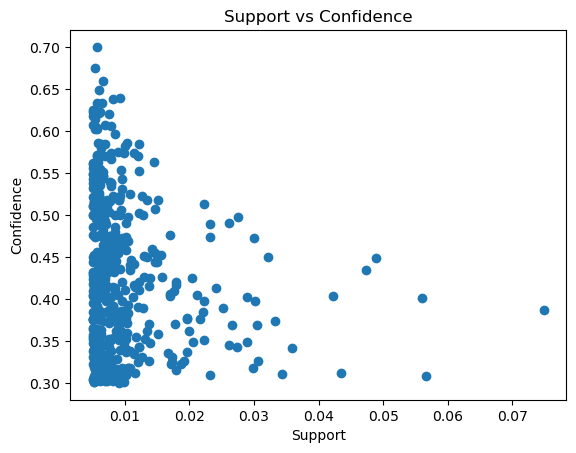

In [47]:
# 17. Support vs Confidence plot
plt.scatter(rules["support"], rules["confidence"])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

In [48]:
# 18. Increase confidence to 0.7
rules_high = association_rules(frequent, metric="confidence", min_threshold=0.7)
print("Rules (confidence ≥ 0.7):", len(rules_high))

Rules (confidence ≥ 0.7): 1


In [49]:
# 19. Lower support to 0.002
frequent_low = apriori(groceries, min_support=0.002, use_colnames=True)

rules_low = association_rules(frequent_low, metric="confidence", min_threshold=0.3)
print("Rules (lower support):", len(rules_low))

Rules (lower support): 3229


In [52]:
# 20. Lift vs Confidence
rules[["confidence", "lift"]].head()

# Lift better captures “unexpectedness” because it adjusts for baseline item frequency, unlike confidence

,confidence,lift
0,0.413793,2.138547
1,0.522989,2.046793
2,0.375969,1.943066
3,0.331395,3.040367
4,0.405039,1.585180


##### PART 3: LDA

In [20]:
# 21. Prepare data
X = df[num_cols]
y = df["species"]

In [22]:
# 22. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [25]:
# 23. LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [27]:
# 24. Confusion matrix
y_pred = lda.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[46  0  0]
 [ 0 21  0]
 [ 1  0 36]]


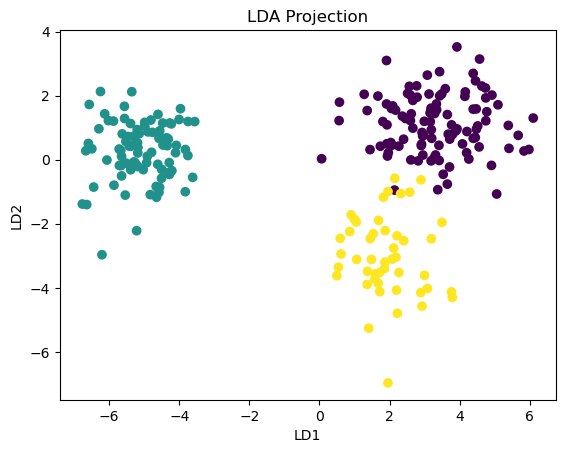

In [29]:
# 25. LD1 vs LD2

X_lda = lda.transform(X_train)

plt.scatter(X_lda[:, 0], X_lda[:, 1], c=pd.factorize(y_train)[0])
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA Projection')
plt.show()

In [31]:
# 26. Number of discriminant functions
print(f'Components: {lda.scalings_.shape[1]}')

# = min(features, classes - 1) = min(4, 2) = 2

Components: 2


In [32]:
# 27. Coefficients
coeff_df = pd.DataFrame(lda.scalings_, index=num_cols)
print(coeff_df)

# Highest absolute value in LD1 → most important feature

                          0         1
bill_length_mm    -0.086870 -0.416636
bill_depth_mm      1.036785 -0.032202
flipper_length_mm -0.096000  0.013388
body_mass_g       -0.001058  0.001698
